#### Dynamic Volatility in Option Pricing & Strategic Risk Analysis


#### 1. Introduction

This project evaluates the assumption of constant volatility in option pricing models.

The original framework uses a binomial tree and Nash equilibrium to evaluate strategic option execution. However, financial markets exhibit time-varying volatility.

This study:
	•	analyzes historical market data
	•	identifies volatility regimes
	•	compares constant vs rolling volatility pricing
	•	evaluates strategic hedging incentives


#### 2. Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import math

#### 3. Download Historical Market Data

We use Apple Inc. (AAPL) as the case study asset.

In [13]:
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01", auto_adjust=True)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103622,178.954960,173.895923,174.013342,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


#### 4. Data Validation

Check for missing values and dataset consistency.

In [14]:
print(data.describe())
print(data.isna().sum())

Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL          AAPL
count   501.000000  501.000000  501.000000  501.000000  5.010000e+02
mean    161.129995  162.793582  159.304202  160.970298  7.359559e+07
std      17.727056   17.459411   17.989137   17.759347  2.536654e+07
min     123.046783  125.753380  122.210234  124.021187  2.404830e+07
25%     146.783539  148.390518  144.907172  146.271103  5.414710e+07
50%     162.036774  163.235204  159.714674  161.644846  6.924600e+07
75%     174.040298  175.522950  172.132648  174.013342  8.670910e+07
max     196.073105  197.567574  194.974473  195.984034  1.826020e+08
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


#### 5. Extract Closing Prices

Adjusted closing prices account for splits and dividends.

In [15]:
prices = data['Close'].squeeze()
prices.head()
S0 = prices.iloc[-1]

#### 6. Compute Log Returns

Log returns measure continuous percentage change.

In [16]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

Date
2022-01-04   -0.012773
2022-01-05   -0.026960
2022-01-06   -0.016834
2022-01-07    0.000988
2022-01-10    0.000116
Name: AAPL, dtype: float64

#### 7. Compute Annual (Constant) Volatility

This represents the traditional assumption.

In [17]:
annual_volatility = log_returns.std() * np.sqrt(252)
annual_volatility

np.float64(0.29041699786215885)

#### 8. Compute Rolling Volatility

Rolling volatility captures time-varying market risk.

In [18]:
vol_20 = log_returns.rolling(20).std() * np.sqrt(252)
vol_30 = log_returns.rolling(30).std() * np.sqrt(252)
vol_60 = log_returns.rolling(60).std() * np.sqrt(252)

#### 9. Visualize Volatility Regimes

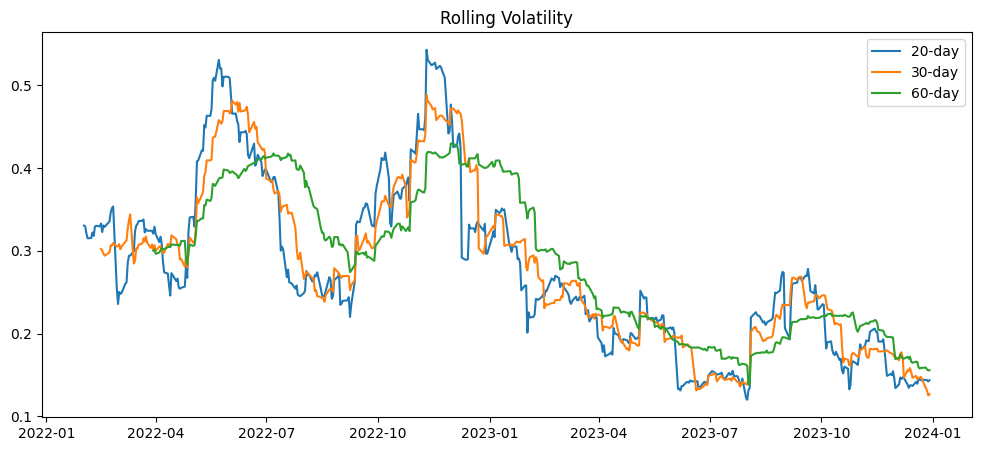

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(12,5))
plt.plot(vol_20, label='20-day')
plt.plot(vol_30, label='30-day')
plt.plot(vol_60, label='60-day')
plt.title("Rolling Volatility")
plt.legend()
plt.show()
plt.savefig("Figure 1: Rolling Volatility Plot.png", dpi=300, bbox_inches='tight')

#### Interpretation

Volatility spikes indicate market stress, while declines indicate stable periods

#### 10. Binomial Option Pricing Function

We implement a binomial tree model for option valuation.

In [20]:
def binomial_option_price(S0, K, r, sigma, T=1, N=100):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # final payoffs
    option_values = np.maximum(
        S0 * (u**np.arange(N, -1, -1)) * (d**np.arange(0, N+1)) - K,
        0
    )

    # backward induction
    for _ in range(N):
        option_values = np.exp(-r * dt) * (
            p * option_values[:-1] +
            (1-p) * option_values[1:]
        )

    return option_values[0]

#### 10A. Visualizing the Binomial Price Tree

This helps understand how future price paths evolve.

In [21]:
def build_binomial_tree(S0, sigma, T=1, N=5):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    tree = []

    for i in range(N + 1):
        level = []
        for j in range(i + 1):
            price = S0 * (u**(i-j)) * (d**j)
            level.append(price)
        tree.append(level)

    return tree

In [22]:
# small tree for visualization
tree = build_binomial_tree(S0, annual_volatility, N=5)

for level in tree:
    print(level)

[np.float64(190.55044555664062)]
[np.float64(216.97787620958007), np.float64(167.34181814353622)]
[np.float64(247.07052574393288), np.float64(190.55044555664062), np.float64(146.9599507772363)]
[np.float64(281.33672316167764), np.float64(216.9778762095801), np.float64(167.34181814353622), np.float64(129.06055026797216)]
[np.float64(320.3552975856898), np.float64(247.07052574393288), np.float64(190.55044555664062), np.float64(146.9599507772363), np.float64(113.34125758329961)]
[np.float64(364.78535591757156), np.float64(281.33672316167764), np.float64(216.97787620958007), np.float64(167.34181814353624), np.float64(129.0605502679722), np.float64(99.53654035947349)]


#### Interpretation

Each level represents possible future prices.
The tree spreads wider as uncertainty increases.

#### 10B. Plot the Binomial Tree

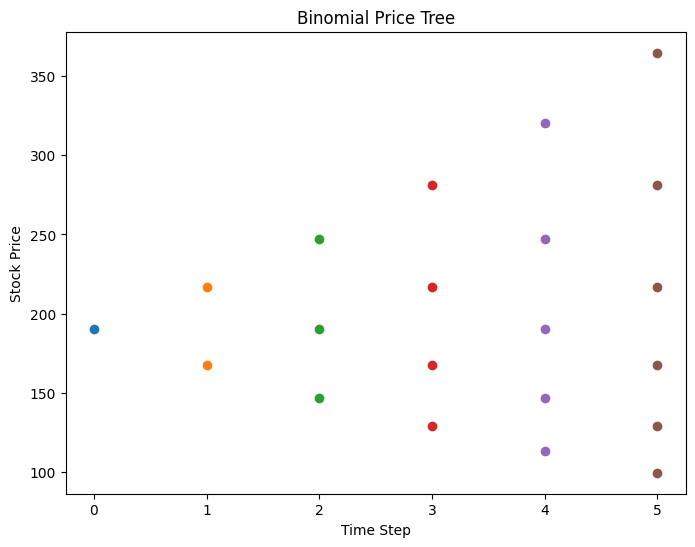

<Figure size 640x480 with 0 Axes>

In [23]:
plt.figure(figsize=(8,6))

for i, level in enumerate(tree):
    x = [i] * len(level)
    plt.scatter(x, level)

plt.title("Binomial Price Tree")
plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.show()
plt.savefig("Figure 2: Binomial Tree Visualization.png", dpi=300, bbox_inches='tight')

#### Interpretation

Wider spread indicates higher uncertainty.

#### 11. Price Option Using Constant Volatility

In [24]:
S0 = prices.iloc[-1]   # ensure scalar
K = S0
r = 0.04

price_constant = binomial_option_price(S0, K, r, annual_volatility)
price_constant

np.float64(25.452701451197722)

#### 12. Price Option Using Rolling Volatility

In [25]:
rolling_sigma = vol_30.dropna()
sigma_dynamic = rolling_sigma.iloc[-1]

price_dynamic = binomial_option_price(S0, K, r, sigma_dynamic)
price_dynamic

np.float64(13.601034287001076)

#### Interpretation

Rolling volatility reflects current market risk and often produces different option values.

#### 13. Compute Option Prices Through Time

In [26]:
option_prices = []
dates = rolling_sigma.index

for date in dates:
    sigma_t = rolling_sigma.loc[date]
    S_t = prices.loc[date]
    option_prices.append(binomial_option_price(S_t, S_t, r, sigma_t))

option_series = pd.Series(option_prices, index=dates)

#### 14. Compare with Constant Volatility Pricing

In [27]:
constant_prices = []

for date in dates:
    S_t = prices.loc[date]
    constant_prices.append(binomial_option_price(S_t, S_t, r, annual_volatility))

constant_series = pd.Series(constant_prices, index=dates)

#### 15. Visual Comparison

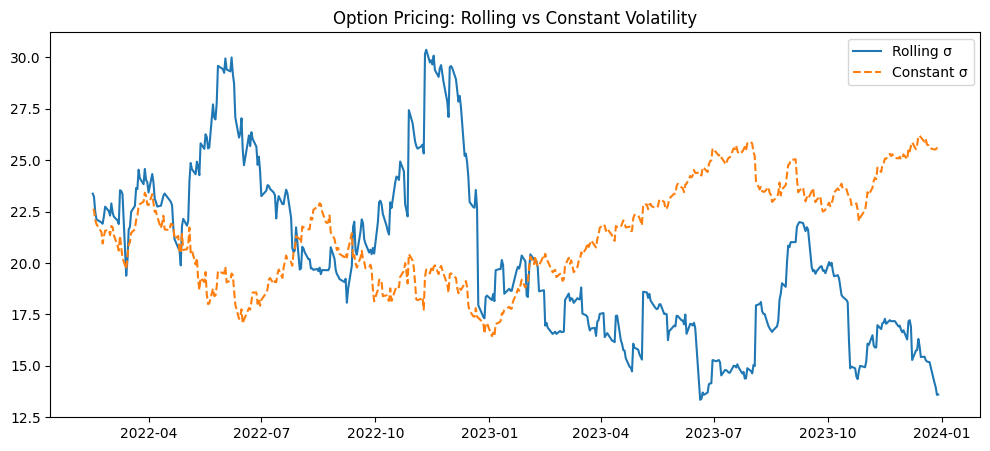

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(12,5))
plt.plot(option_series, label="Rolling σ")
plt.plot(constant_series, linestyle='--', label="Constant σ")
plt.legend()
plt.title("Option Pricing: Rolling vs Constant Volatility")
plt.show()
plt.savefig("Figure 3: Constant vs Rolling Option Prices.png", dpi=300, bbox_inches='tight')

#### Interpretation

Rolling volatility responds to market regimes, while constant volatility remains rigid.

#### 16. Quantify Mispricing

In [29]:
difference = constant_series - option_series

difference.mean(), difference.std(), difference.max(), difference.min()

(np.float64(1.263249556528889),
 5.879291091543936,
 12.00484370628639,
 -10.860100752141541)

#### Interpretation

Constant volatility leads to regime-dependent pricing errors.

#### 17. Compute Expected Payoff at Expiration

We compute the payoff and its risk-neutral expected value.

In [30]:
def expected_payoff(S0, K, r, sigma, T=1, N=100):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # possible prices at maturity
    ST = S0 * (u**np.arange(N, -1, -1)) * (d**np.arange(0, N+1))

    payoff = np.maximum(ST - K, 0)

    # binomial probabilities
    probs = [math.comb(N, k) * (p**(N-k)) * ((1-p)**k) for k in range(N+1)]

    expected = np.sum(payoff * probs)

    return payoff, probs, expected

#### 18. Compute Expected Payoff (Current Volatility)

In [31]:
payoff_high, probs_high, expected_high = expected_payoff(
    S0, K, r, annual_volatility
)

expected_high

np.float64(26.491445902708772)

#### 19. Visualize Payoff Distribution

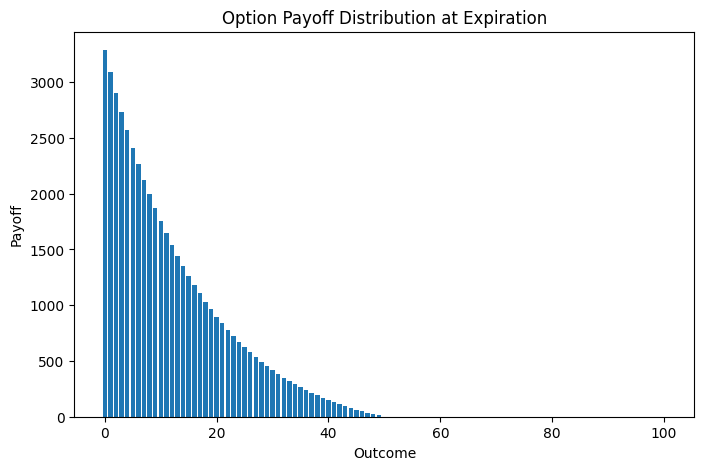

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(8,5))
plt.bar(range(len(payoff_high)), payoff_high)
plt.title("Option Payoff Distribution at Expiration")
plt.xlabel("Outcome")
plt.ylabel("Payoff")
plt.show()
plt.savefig("Figure 4: Payoff Distribution.png", dpi=300, bbox_inches='tight')

#### Interpretation

Shows possible profits for the option holder.

#### 20. Construct Game Theory Payoff Matrix

In [33]:
hedge_cost = 5

payoff_matrix = {
    "Hold": [0, 0],
    "Execute": [expected_high, expected_high - hedge_cost]
}

payoff_matrix

{'Hold': [0, 0],
 'Execute': [np.float64(26.491445902708772), np.float64(21.491445902708772)]}

#### Interpretation

The holder executes if profitable; the writer hedges to reduce losses.

#### 21. Compute Expected Payoff Under Low Volatility

In [34]:
sigma_low = 0.15

payoff_low, probs_low, expected_low = expected_payoff(
    S0, K, r, sigma_low
)
expected_low

np.float64(15.892884493917125)

#### 22. Construct Low-Volatility Payoff Matrix

In [35]:
low_matrix = {
    "Hold": [0, 0],
    "Execute": [expected_low, expected_low - hedge_cost]
}

low_matrix

{'Hold': [0, 0],
 'Execute': [np.float64(15.892884493917125), np.float64(10.892884493917125)]}

#### Interpretation

Lower volatility reduces potential losses and hedging urgency.

#### 23. Find Volatility Threshold for Hedging

In [36]:
threshold = None

for s in np.linspace(0.01, 0.30, 100):
    _, _, exp_pay = expected_payoff(S0, K, r, s)
    if exp_pay >= hedge_cost:
        threshold = s
        break

threshold

np.float64(0.01)

#### Interpretation

This is the volatility level where hedging becomes economically justified.

#### Final Summary: Volatility and Option Pricing Dynamics

This figure summarizes how changing market volatility affects option prices and highlights the limitations of constant-volatility pricing.

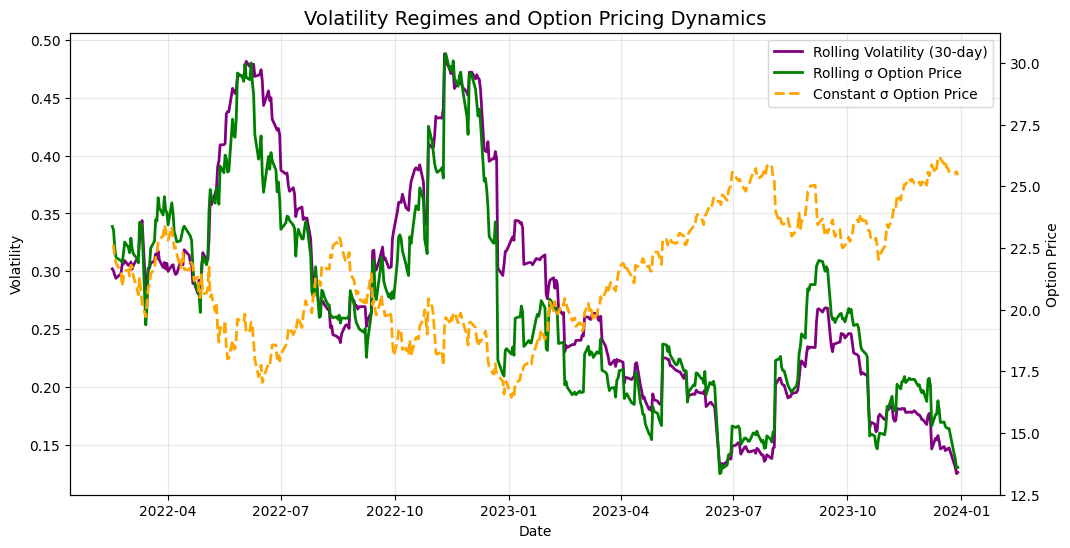

<Figure size 640x480 with 0 Axes>

In [37]:
fig, ax1 = plt.subplots(figsize=(12,6))

# LEFT AXIS — Volatility
line1 = ax1.plot(vol_30,
                 color='purple',
                 linewidth=2,
                 label='Rolling Volatility (30-day)')
ax1.set_ylabel("Volatility")
ax1.set_xlabel("Date")

# RIGHT AXIS — Option Prices
ax2 = ax1.twinx()

line2 = ax2.plot(option_series,
                 color='green',
                 linewidth=2,
                 label='Rolling σ Option Price')

line3 = ax2.plot(constant_series,
                 color='orange',
                 linestyle='--',
                 linewidth=2,
                 label='Constant σ Option Price')

ax2.set_ylabel("Option Price")

# Combine legend entries cleanly
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="upper right")

ax1.grid(alpha=0.3)

plt.title("Volatility Regimes and Option Pricing Dynamics", fontsize=14)
plt.show()
plt.savefig("Figure 5: Final Summary Visualization.png", dpi=300, bbox_inches='tight')

In [1]:
import os
os.getcwd()

'/Users/admin'